# Classical PCA vs Quantum Oracle Sketching — Vehicle Trajectory Benchmark

**Goal**: Compare how efficiently each paradigm recovers the dominant variance of the
vehicle trajectory feature matrix as a function of *machine size* (memory/qubits).

Three competing methods (mirroring the QOS paper's real-dataset experiments):

| Method | Machine size metric |
|---|---|
| Classical streaming PCA | # features kept (*d* floats) |
| Classical sparse / QRAM | # non-zero entries stored (*nnz* floats) |
| Quantum oracle sketching (QOS) | # qubits = 2⌈log₂(n+d)⌉ + ⌈log₂(s)⌉ + 4 |

**Relevant QOS source files used:**
- `quantum-oracle-sketching/real_datasets/dorothea_pca.py` — benchmark template (feature-truncation sweep + variance-recovery formula)
- `quantum-oracle-sketching/qos.py` — `q_oracle_sketch_matrix_element(X, M)` for the actual QOS simulation
- `quantum-oracle-sketching/utils.py` — JAX float64 config and dtype constants
- `quantum-oracle-sketching/data_generation.py` — `matrix_data` oracle-access interface

## 1. Imports & Setup

In [1]:
import sys, os, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.linalg import svd
from scipy.sparse.linalg import svds
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from tqdm.auto import tqdm

# ── Add the cloned QOS repository to the Python path ───────────────────────────
QOS_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')),
                       'quantum-oracle-sketching')
if QOS_DIR not in sys.path:
    sys.path.insert(0, QOS_DIR)

# ── Try importing JAX + QOS (optional: falls back gracefully if not installed) ─
QOS_AVAILABLE = False
try:
    import jax
    import jax.numpy as jnp
    from jax import random as jrandom
    import utils as qos_utils          # quantum-oracle-sketching/utils.py
    import qos                         # quantum-oracle-sketching/qos.py
    jax.config.update("jax_enable_x64", True)
    QOS_AVAILABLE = True
    print(f"✓  JAX {jax.__version__} loaded — QOS simulation enabled")
    print(f"   Devices: {jax.devices()}")
except ImportError as e:
    print(f"⚠  JAX / QOS not importable ({e}). Theoretical-only mode.")

%matplotlib inline
plt.rcParams['figure.dpi'] = 130
sns.set_theme(style='whitegrid', font_scale=1.05)
print("✓  Classical libraries loaded")

/Users/dmitriikhitrin/anaconda3/envs/dry-dock/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓  JAX 0.6.2 loaded — QOS simulation enabled
   Devices: [CpuDevice(id=0)]
✓  Classical libraries loaded


## 2. Load & Preprocess Vehicle Trajectory Data

Same pipeline as `pca_vehicles.ipynb`:
run `extract_features.py` → filter VEHICLE class → speed filter → drop spatial columns → `StandardScaler`.

In [2]:
# ── CONFIG (mirror pca_vehicles.ipynb) ────────────────────────────────────────
INPUT_JSON   = '20241003-7.json'
OUTPUT_CSV   = 'output_trajectory_features.csv'
POINTS       = 10          # spatial waypoints per trajectory
FILTER_CLASS = 'VEHICLE'
MIN_SPEED    = 5.0         # m/s
MAGNITUDE_ONLY = True      # drop delta_x/y and x_*/y_* spatial columns

DELTA_X_RANGE = [(-10, 10), (20, 60)]
DELTA_Y_RANGE = [(-120, -50), (-25, 25)]

# ── Run feature extractor ─────────────────────────────────────────────────────
result = subprocess.run(
    [sys.executable, 'extract_features.py', INPUT_JSON, OUTPUT_CSV,
     '-t', 'trajectory', '-p', str(POINTS)],
    capture_output=True, text=True
)
if result.returncode != 0:
    raise RuntimeError('Feature extraction failed:\n' + result.stderr[-1000:])
print(result.stdout[-1500:])

# ── Load CSV ──────────────────────────────────────────────────────────────────
df = pd.read_csv(OUTPUT_CSV)
dup_mask = df['object_id'].duplicated(keep=False)
df = df[~dup_mask].reset_index(drop=True)
print(f'\nAfter dedup: {len(df):,} rows')



After dedup: 10,927 rows


In [3]:
FEATURE_COLS = [c for c in df.columns
                if df[c].dtype == float and c not in ('object_id', 'intersection_id')]

# ── Spatial range filter ──────────────────────────────────────────────────────
def _range_mask(dx, dy, x_ranges, y_ranges):
    if x_ranges is None:
        return pd.Series(True, index=dx.index)
    mask = pd.Series(False, index=dx.index)
    for (xlo, xhi), (ylo, yhi) in zip(x_ranges, y_ranges):
        mask |= dx.between(xlo, xhi) & dy.between(ylo, yhi)
    return mask

data = df[df['classification'] == FILTER_CLASS].copy() if FILTER_CLASS else df.copy()
data = data[_range_mask(data['delta_x'], data['delta_y'], DELTA_X_RANGE, DELTA_Y_RANGE)]

# ── NaN / inf cleanup ─────────────────────────────────────────────────────────
data[FEATURE_COLS] = data[FEATURE_COLS].replace([np.inf, -np.inf], np.nan)
data = data.dropna(subset=FEATURE_COLS)

# ── Speed filter ──────────────────────────────────────────────────────────────
data = data[data['vel_mean'] >= MIN_SPEED].copy()

# ── Feature selection ─────────────────────────────────────────────────────────
DIRECTIONAL_EXACT    = {'delta_x', 'delta_y'}
DIRECTIONAL_PREFIXES = ('x_', 'y_')

if MAGNITUDE_ONLY:
    active_cols = [c for c in FEATURE_COLS
                   if c not in DIRECTIONAL_EXACT
                   and not any(c.startswith(p) for p in DIRECTIONAL_PREFIXES)]
else:
    active_cols = FEATURE_COLS

X_raw    = data[active_cols].values
labels   = data['sub_classification'].values
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

n_samples, n_features = X_scaled.shape
print(f'Final matrix shape : {X_scaled.shape}  (samples × features)')
print(f'Features           : {active_cols}')
print(f'Sub-class counts   :\n{pd.Series(labels).value_counts().to_string()}')

Final matrix shape : (3426, 32)  (samples × features)
Features           : ['vel_min', 'vel_max', 'vel_mean', 'vel_std', 'acc_min', 'acc_max', 'acc_mean', 'acc_std', 'jerk_min', 'jerk_max', 'jerk_mean', 'jerk_std', 'acc_dir_min', 'acc_dir_max', 'acc_dir_mean', 'acc_dir_std', 'jerk_dir_min', 'jerk_dir_max', 'jerk_dir_mean', 'jerk_dir_std', 'curv_min', 'curv_max', 'curv_mean', 'curv_std', 'path', 'delta_t', 'frac_stop', 'frac_accel', 'frac_break', 'obj_length', 'obj_width', 'obj_height']
Sub-class counts   :
car      3246
truck     180


## 3. Ground-Truth: Full SVD

The ground-truth top right singular vector **v₁** of the full data matrix X defines the
direction that captures the most variance.  All downstream methods are judged on how well
their reduced representation recovers this variance:

```
variance_recovery = ‖X @ v_approx‖² / ‖X @ v₁‖²  ∈ [0, 1]
```

This mirrors `dorothea_pca.py → get_pca_results_full()` from the QOS repo.

Data matrix            : (3426, 32)
Singular values (top5) : [173.034 121.413 108.44   93.433  85.668]
Top-1 variance share   : 27.3%
var_max (‖X@v₁‖²)     : 29940.8641
PCs for 90% variance   : 12
PCs for 95% variance   : 14


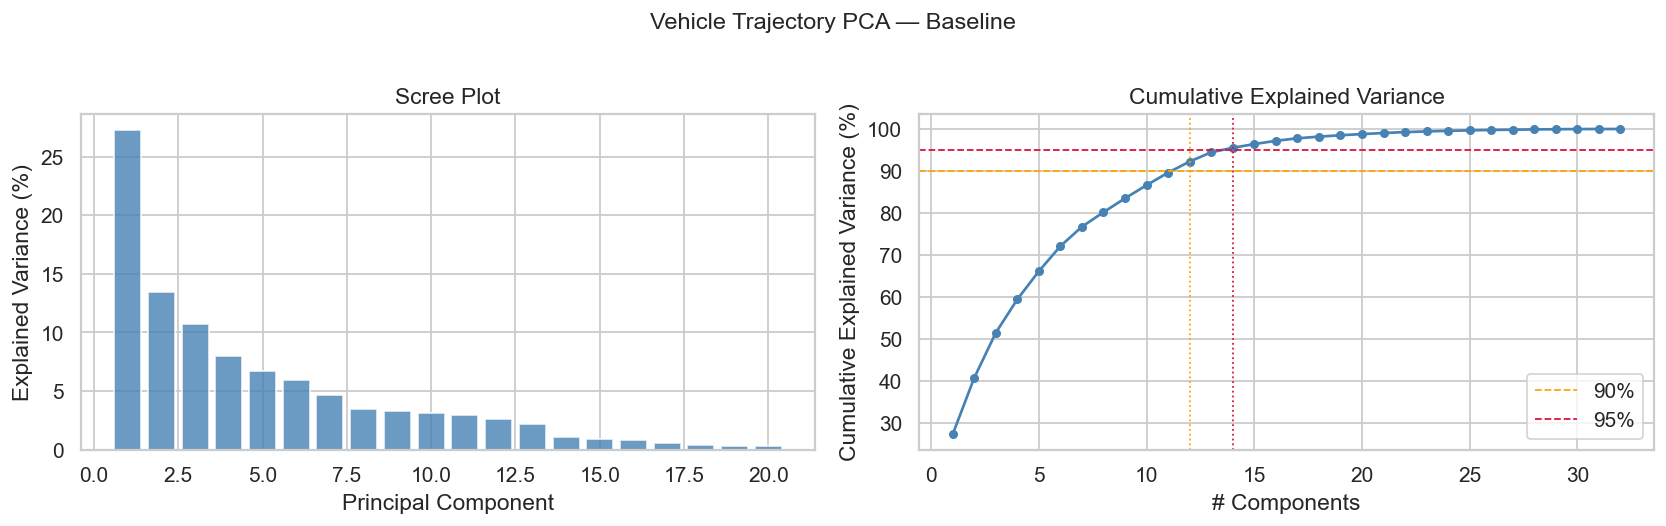

In [4]:
np.random.seed(42)

# Full SVD — X_scaled is (n_samples × n_features), usually n >> d so full SVD is cheap
U_full, S_full, Vt_full = svd(X_scaled, full_matrices=False)

v1_full   = Vt_full[0]                            # top right singular vector, shape (d,)
var_max   = np.linalg.norm(X_scaled @ v1_full)**2  # maximum achievable projected variance

# Baseline classical PCA for context
pca_full   = PCA(random_state=42).fit(X_scaled)
cumvar     = np.cumsum(pca_full.explained_variance_ratio_)
n_90       = int(np.argmax(cumvar >= 0.90)) + 1
n_95       = int(np.argmax(cumvar >= 0.95)) + 1

print(f'Data matrix            : {X_scaled.shape}')
print(f'Singular values (top5) : {np.round(S_full[:5], 3)}')
print(f'Top-1 variance share   : {S_full[0]**2 / np.sum(S_full**2)*100:.1f}%')
print(f'var_max (‖X@v₁‖²)     : {var_max:.4f}')
print(f'PCs for 90% variance   : {n_90}')
print(f'PCs for 95% variance   : {n_95}')

# ── Scree + cumulative variance plot ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

n_show = min(20, len(S_full))
axes[0].bar(range(1, n_show + 1), pca_full.explained_variance_ratio_[:n_show] * 100,
            color='steelblue', alpha=0.8)
axes[0].set(xlabel='Principal Component', ylabel='Explained Variance (%)',
            title='Scree Plot')

axes[1].plot(range(1, len(cumvar) + 1), cumvar * 100, marker='o', markersize=4, color='steelblue')
axes[1].axhline(90, color='orange', linestyle='--', linewidth=1, label='90%')
axes[1].axhline(95, color='crimson', linestyle='--', linewidth=1, label='95%')
axes[1].axvline(n_90, color='orange', linestyle=':', linewidth=1)
axes[1].axvline(n_95, color='crimson', linestyle=':', linewidth=1)
axes[1].set(xlabel='# Components', ylabel='Cumulative Explained Variance (%)',
            title='Cumulative Explained Variance')
axes[1].legend()
plt.suptitle('Vehicle Trajectory PCA — Baseline', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 4. Classical Feature-Truncation Sweep

**Algorithm** (adapted directly from `dorothea_pca.py → get_pca_results_full()`):

1. Rank features by descending column variance (the most informative features first).
2. For each truncation level *k* = 1 … *d*:
   - Keep only the top-*k* features → `X_trunc` of shape (*n*, *k*).
   - Compute the top right singular vector of `X_trunc` via `svds`.
   - **Lift** it back to the full *d*-dimensional space (zero-pad dropped features).
   - Compute `variance_recovery = ‖X @ v_lifted‖² / var_max`.
   - Record machine sizes for all three methods.

**Machine size formulae:**

| Method | Formula |
|---|---|
| Streaming | `space = k` (number of feature columns) |
| Sparse/QRAM | `space = n × k` (all entries are nonzero for dense data) |
| Quantum (QOS) | `space = 2⌈log₂(n+k+1)⌉ + ⌈log₂(max(k,n)+1)⌉ + 4` qubits |

The quantum formula comes from the QOS qubit register sizes:
- Two registers of size `⌈log₂(n+k+1)⌉` for row/column indices
- One sparsity register of size `⌈log₂(sparsity+1)⌉`
- 4 ancilla qubits

In [5]:
def qos_qubit_count(n, k):
    """
    Theoretical qubit count for the QOS element oracle on an (n × k) dense matrix.
    Formula from dorothea_pca.py:
        2 * ceil(log2(n + k + 1))  — row + column index registers
      + ceil(log2(sparsity + 1))   — sparsity register (= max(k, n) for dense data)
      + 4                          — ancilla qubits
    """
    if n + k + 1 <= 1:
        return 4
    reg_idx  = 2 * int(np.ceil(np.log2(n + k + 1)))
    sparsity = max(k, n)           # dense matrix: row_sparsity=k, col_sparsity=n
    reg_spar = int(np.ceil(np.log2(sparsity + 1)))
    return reg_idx + reg_spar + 4


# ── Rank features by ABSOLUTE LOADING on the top right singular vector ────────
# StandardScaler makes all column variances equal to 1, so column variance is
# uninformative for ordering. Instead we use |v1[i]|: features that contribute
# the most to the dominant direction of variation are kept first.
feat_order   = np.argsort(np.abs(v1_full))[::-1]   # most-informative first
sorted_names = [active_cols[i] for i in feat_order]

print("Features ranked by |loading on top singular vector| (descending):")
for rank, (name, idx) in enumerate(zip(sorted_names, feat_order), 1):
    loading = v1_full[idx]
    bar = '█' * int(abs(loading) * 120)
    sign = '+' if loading > 0 else '-'
    print(f"  {rank:2d}. {sign}{bar:<30s}  {name:<35s}  |v₁|={abs(loading):.4f}")

# ── Sweep k = 1 … d ──────────────────────────────────────────────────────────
sweep_results = {
    'k':                  [],
    'feature_names':      [],
    'variance_recovery':  [],
    'space_streaming':    [],
    'space_sparse':       [],
    'space_quantum':      [],
}

for k in tqdm(range(1, n_features + 1), desc="Feature-truncation sweep"):
    keep_idx  = feat_order[:k]              # top-k features by PC1 loading
    X_trunc   = X_scaled[:, keep_idx]      # (n, k)

    # Top right singular vector of X_trunc
    if k == 1:
        v_trunc = np.array([1.0])
    else:
        try:
            _, _, Vt_trunc = svds(X_trunc, k=1)
            v_trunc = Vt_trunc[0]
        except Exception:
            _, _, Vt_trunc = svd(X_trunc, full_matrices=False)
            v_trunc = Vt_trunc[0]

    # Lift back to full d-dimensional space
    v_lifted         = np.zeros(n_features)
    v_lifted[keep_idx] = v_trunc
    norm             = np.linalg.norm(v_lifted)
    if norm > 0:
        v_lifted /= norm

    var_captured  = np.linalg.norm(X_scaled @ v_lifted)**2
    recovery      = var_captured / var_max

    # Machine sizes
    nnz           = n_samples * k          # dense: every entry is nonzero
    space_stream  = k
    space_sparse  = nnz
    space_quantum = qos_qubit_count(n_samples, k)

    sweep_results['k'].append(k)
    sweep_results['feature_names'].append(sorted_names[:k])
    sweep_results['variance_recovery'].append(recovery)
    sweep_results['space_streaming'].append(space_stream)
    sweep_results['space_sparse'].append(space_sparse)
    sweep_results['space_quantum'].append(space_quantum)

sweep_df = pd.DataFrame({c: v for c, v in sweep_results.items() if c != 'feature_names'})
print(sweep_df.to_string(index=False))

Features ranked by |loading on top singular vector| (descending):
   1. +████████████████████████████████████  acc_std                              |v₁|=0.3069
   2. +████████████████████████████████████  jerk_mean                            |v₁|=0.3003
   3. +███████████████████████████████████  jerk_std                             |v₁|=0.2999
   4. +██████████████████████████████████  acc_mean                             |v₁|=0.2912
   5. +█████████████████████████████████  acc_max                              |v₁|=0.2814
   6. +█████████████████████████████████  jerk_dir_std                         |v₁|=0.2803
   7. +████████████████████████████████  jerk_max                             |v₁|=0.2742
   8. +████████████████████████████████  acc_dir_std                          |v₁|=0.2711
   9. -███████████████████████████     jerk_dir_min                         |v₁|=0.2265
  10. +███████████████████████████     jerk_dir_max                         |v₁|=0.2251
  11. +████████████████

Feature-truncation sweep: 100%|██████████| 32/32 [00:00<00:00, 798.44it/s]

 k  variance_recovery  space_streaming  space_sparse  space_quantum
 1           0.114426                1          3426             40
 2           0.217296                2          6852             40
 3           0.325029                3         10278             40
 4           0.422949                4         13704             40
 5           0.512205                5         17130             40
 6           0.563365                6         20556             40
 7           0.656784                7         23982             40
 8           0.706833                8         27408             40
 9           0.753410                9         30834             40
10           0.804016               10         34260             40
11           0.848234               11         37686             40
12           0.870791               12         41112             40
13           0.892490               13         44538             40
14           0.914686               14         4

## 5. Efficiency Frontier: Machine Size vs Variance Recovery

Reproduces the QOS paper's core figure for the vehicle trajectory data.

- **x-axis**: variance recovery ∈ [0, 1]
- **y-axis** (log scale): machine size needed to achieve that recovery

A curve that sits **lower** = more memory-efficient.

/var/folders/d9/vp7jkvm979jc2_fkp1g0jxzm0000gn/T/ipykernel_51442/3104151230.py:53: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/Users/dmitriikhitrin/anaconda3/envs/dry-dock/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


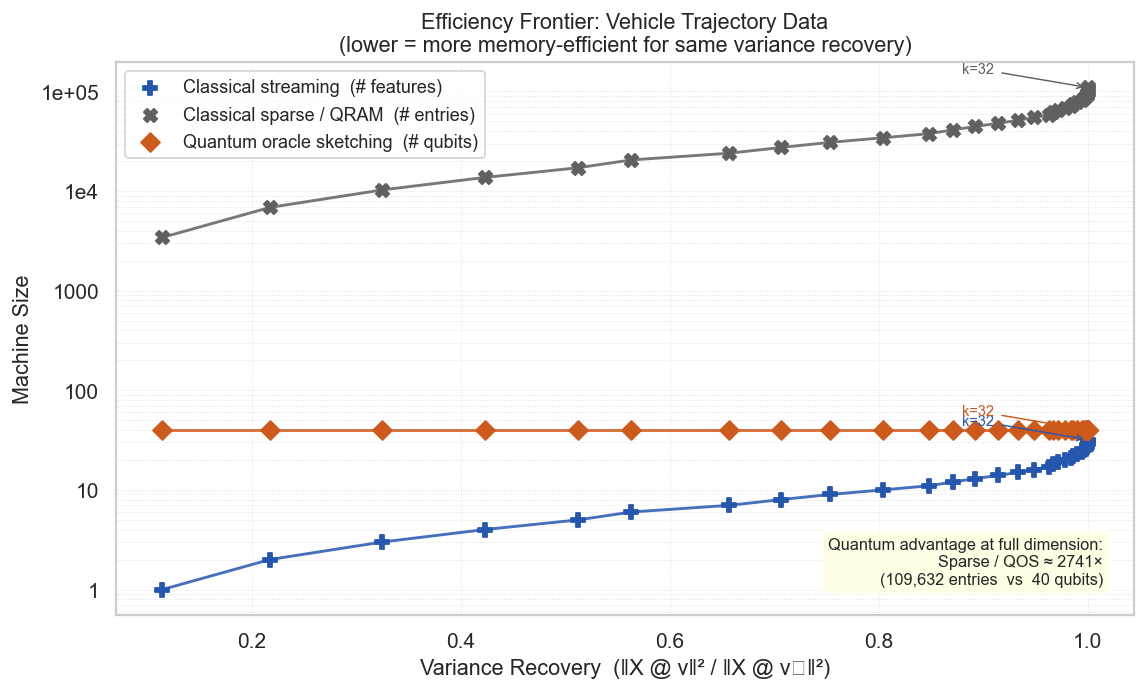

In [6]:
# ── Colour / marker palette (mirrors QOS paper) ───────────────────────────────
COLORS  = {'streaming': '#2657AF', 'sparse': '#606060', 'quantum': '#CD591A'}
MARKERS = {'streaming': 'P', 'sparse': 'X', 'quantum': 'D'}
LABELS  = {
    'streaming': 'Classical streaming  (# features)',
    'sparse':    'Classical sparse / QRAM  (# entries)',
    'quantum':   'Quantum oracle sketching  (# qubits)',
}

rec  = np.array(sweep_df['variance_recovery'])
sstr = np.array(sweep_df['space_streaming'])
sspa = np.array(sweep_df['space_sparse'])
squa = np.array(sweep_df['space_quantum'])

# Sort each curve by variance_recovery for a clean parametric plot
def _sorted(recovery_arr, space_arr):
    order = np.argsort(recovery_arr)
    return recovery_arr[order], space_arr[order]

fig, ax = plt.subplots(figsize=(9, 5.5))

for key, space in [('streaming', sstr), ('sparse', sspa), ('quantum', squa)]:
    rx, sx = _sorted(rec, space)
    ax.plot(rx, sx, '-', color=COLORS[key], linewidth=1.6, alpha=0.85)
    ax.scatter(rx, sx, marker=MARKERS[key], color=COLORS[key],
               label=LABELS[key], s=55, zorder=3)

# Annotate the full-dimension point on each curve
for key, space in [('streaming', sstr[-1]), ('sparse', sspa[-1]), ('quantum', squa[-1])]:
    ax.annotate(f'k={n_features}', xy=(rec[-1], space),
                xytext=(rec[-1] - 0.12, space * 1.4),
                fontsize=8, color=COLORS[key],
                arrowprops=dict(arrowstyle='->', color=COLORS[key], lw=0.8))

ax.set_yscale('log')
ax.set_xlabel('Variance Recovery  (‖X @ v‖² / ‖X @ v₁‖²)', fontsize=12)
ax.set_ylabel('Machine Size', fontsize=12)
ax.set_title('Efficiency Frontier: Vehicle Trajectory Data\n'
             '(lower = more memory-efficient for same variance recovery)', fontsize=12)
ax.legend(fontsize=10, loc='upper left')
ax.yaxis.set_major_formatter(mticker.LogFormatter())
ax.grid(True, which='both', linestyle=':', linewidth=0.5, alpha=0.6)

# Secondary annotation: quantum advantage factor at full recovery
adv_factor = sspa[-1] / squa[-1]
ax.text(0.97, 0.05,
        f'Quantum advantage at full dimension:\n'
        f'  Sparse / QOS ≈ {adv_factor:.0f}×\n'
        f'  ({sspa[-1]:,} entries  vs  {squa[-1]} qubits)',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

## 6. QOS Simulation: Multi-PC Extraction vs Classical PCA

Uses `qos.q_oracle_sketch_matrix_element(X_norm, M)` to build a sketched matrix, then extracts **up to `n_95` principal components** via `svds`.

**Two sweeps are run:**
1. **M-sweep (k=1)** — varies oracle budget M; measures how quickly PC1 recovery converges to the classical ground truth.
2. **k-sweep (large M)** — fixes M at a large value and extracts PCs 1…`n_95`; compares per-PC variance recovery and PC direction alignment against classical PCA.

All downstream comparisons (scatter plots, cosine similarity) use the **classical `X_scaled`** projected onto QOS-estimated directions — isolating the quality of the estimated directions from any sketching noise in the projection step.

In [11]:
if not QOS_AVAILABLE:
    print("⚠  JAX / QOS not available — skipping QOS simulation. "
          "Install requirements: pip install jax jaxlib pyqsp")
else:
    # ── Normalise X to [-1, 1] (required by q_oracle_sketch_matrix_element) ───
    abs_max = np.abs(X_scaled).max()
    X_norm  = X_scaled / abs_max
    X_jax   = jnp.array(X_norm, dtype=qos_utils.real_dtype)

    # total variance = sum of all squared singular values (denominator for proper % explained)
    total_variance = float(np.sum(S_full**2))
    print(f"X_norm |max|     = {np.abs(X_norm).max():.6f}  (must be ≤ 1.0)")
    print(f"X_norm shape     = {X_jax.shape}")
    print(f"var_max (PC1)    = {var_max:.4f}   (‖X @ v₁‖²)")
    print(f"total_variance   = {total_variance:.4f}   (sum of all σᵢ²)")
    print(f"PC1 share        = {var_max/total_variance*100:.1f}% of total variance")

    # ════════════════════════════════════════════════════════════════════════════
    # SWEEP 1 — vary M, extract k=1 PC only (convergence curve)
    # Uses var_max as denominator — this is the QOS paper's "PC1 recovery" metric
    # ════════════════════════════════════════════════════════════════════════════
    M_values = [5, 10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10_000]

    qos_results = {'M': [], 'variance_recovery': [], 'frob_err': []}

    for M in tqdm(M_values, desc="QOS M-sweep (k=1)"):
        sketch_diag, _ = qos.q_oracle_sketch_matrix_element(X_jax, M)
        sketched_mat   = np.array(sketch_diag.real).reshape(n_samples, n_features) * abs_max

        frob_err = (np.linalg.norm(sketched_mat - X_scaled, 'fro')
                    / np.linalg.norm(X_scaled, 'fro'))

        try:
            _, _, Vt_s = svds(sketched_mat, k=1)
            v_s = Vt_s[0]
        except Exception:
            _, _, Vt_s = svd(sketched_mat, full_matrices=False)
            v_s = Vt_s[0]

        v_s /= (np.linalg.norm(v_s) + 1e-12)
        # recovery relative to var_max (PC1 benchmark, matches QOS paper)
        var_rec = np.linalg.norm(X_scaled @ v_s)**2 / var_max

        qos_results['M'].append(M)
        qos_results['variance_recovery'].append(float(var_rec))
        qos_results['frob_err'].append(float(frob_err))
        tqdm.write(f"  M={M:>6d} | var_rec(vs PC1)={var_rec:.4f} | frob_err={frob_err:.4f}")

    qos_df = pd.DataFrame(qos_results)

    # ════════════════════════════════════════════════════════════════════════════
    # SWEEP 2 — large M, extract k = 1…n_95 PCs
    # Uses total_variance as denominator — proper "% of total variance explained"
    # ════════════════════════════════════════════════════════════════════════════
    M_LARGE   = 10_000
    K_COMPARE = n_95

    print(f"\nExtracting {K_COMPARE} PCs from QOS sketch at M={M_LARGE} …")
    sketch_diag_large, _ = qos.q_oracle_sketch_matrix_element(X_jax, M_LARGE)
    X_sketched = np.array(sketch_diag_large.real).reshape(n_samples, n_features) * abs_max

    from scipy.sparse.linalg import svds as _svds
    U_qos, S_qos, Vt_qos = _svds(X_sketched, k=K_COMPARE)
    order  = np.argsort(S_qos)[::-1]
    S_qos  = S_qos[order]
    Vt_qos = Vt_qos[order]       # shape (K_COMPARE, n_features)

    # Classical reference PCs (top K_COMPARE), already sorted descending
    Vt_classical = Vt_full[:K_COMPARE]

    # Project original X_scaled onto the estimated directions
    X_pca_classical = X_scaled @ Vt_classical.T    # (n, K_COMPARE)
    X_pca_qos       = X_scaled @ Vt_qos.T          # (n, K_COMPARE)

    # Per-PC variance explained as % of TOTAL variance (proper PCA metric, sums to ≤100%)
    var_per_pc_classical = np.array([
        np.linalg.norm(X_scaled @ Vt_classical[i])**2 / total_variance
        for i in range(K_COMPARE)
    ])
    var_per_pc_qos = np.array([
        np.linalg.norm(X_scaled @ Vt_qos[i])**2 / total_variance
        for i in range(K_COMPARE)
    ])

    # Cosine similarity matrix (absolute value — sign of PC direction is arbitrary)
    cos_sim = np.abs(Vt_qos @ Vt_classical.T)   # (K_COMPARE, K_COMPARE)

    print(f"\nPer-PC variance explained  (% of total variance — classical vs QOS at M={M_LARGE:,}):")
    print(f"  {'PC':<6} {'Classical %':>13} {'QOS %':>9} {'Δ %':>8}")
    for i in range(K_COMPARE):
        delta = var_per_pc_qos[i] - var_per_pc_classical[i]
        print(f"  PC{i+1:<4} {var_per_pc_classical[i]*100:>13.2f} {var_per_pc_qos[i]*100:>9.2f} {delta*100:>+8.2f}")
    print(f"\n  Classical cumulative (k={K_COMPARE}): {np.sum(var_per_pc_classical)*100:.1f}%")
    print(f"  QOS       cumulative (k={K_COMPARE}): {np.sum(var_per_pc_qos)*100:.1f}%")


X_norm |max|     = 1.000000  (must be ≤ 1.0)
X_norm shape     = (3426, 32)
var_max (PC1)    = 29940.8641   (‖X @ v₁‖²)
total_variance   = 109632.0000   (sum of all σᵢ²)
PC1 share        = 27.3% of total variance


QOS M-sweep (k=1):   0%|          | 0/11 [00:00<?, ?it/s]

QOS M-sweep (k=1): 100%|██████████| 11/11 [00:00<00:00, 79.80it/s]

  M=     5 | var_rec(vs PC1)=0.0970 | frob_err=1.0000
  M=    10 | var_rec(vs PC1)=0.1273 | frob_err=1.0000
  M=    20 | var_rec(vs PC1)=0.1265 | frob_err=1.0000
  M=    50 | var_rec(vs PC1)=0.1705 | frob_err=0.9999
  M=   100 | var_rec(vs PC1)=0.1435 | frob_err=1.0003
  M=   200 | var_rec(vs PC1)=0.1762 | frob_err=1.0025
  M=   500 | var_rec(vs PC1)=0.3028 | frob_err=1.0094
  M=  1000 | var_rec(vs PC1)=0.8830 | frob_err=0.9276
  M=  2000 | var_rec(vs PC1)=0.9787 | frob_err=0.7809
  M=  5000 | var_rec(vs PC1)=0.9865 | frob_err=0.5644
  M= 10000 | var_rec(vs PC1)=0.9926 | frob_err=0.4857

Extracting 14 PCs from QOS sketch at M=10000 …

Per-PC variance explained  (% of total variance — classical vs QOS at M=10,000):
  PC       Classical %     QOS %      Δ %
  PC1            27.31     27.11    -0.20
  PC2            13.45     12.71    -0.73
  PC3            10.73      9.90    -0.83
  PC4             7.96      8.25    +0.29
  PC5             6.69      5.65    -1.05
  PC6             5.97  

/var/folders/d9/vp7jkvm979jc2_fkp1g0jxzm0000gn/T/ipykernel_51442/446605676.py:85: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/Users/dmitriikhitrin/anaconda3/envs/dry-dock/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dmitriikhitrin/anaconda3/envs/dry-dock/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


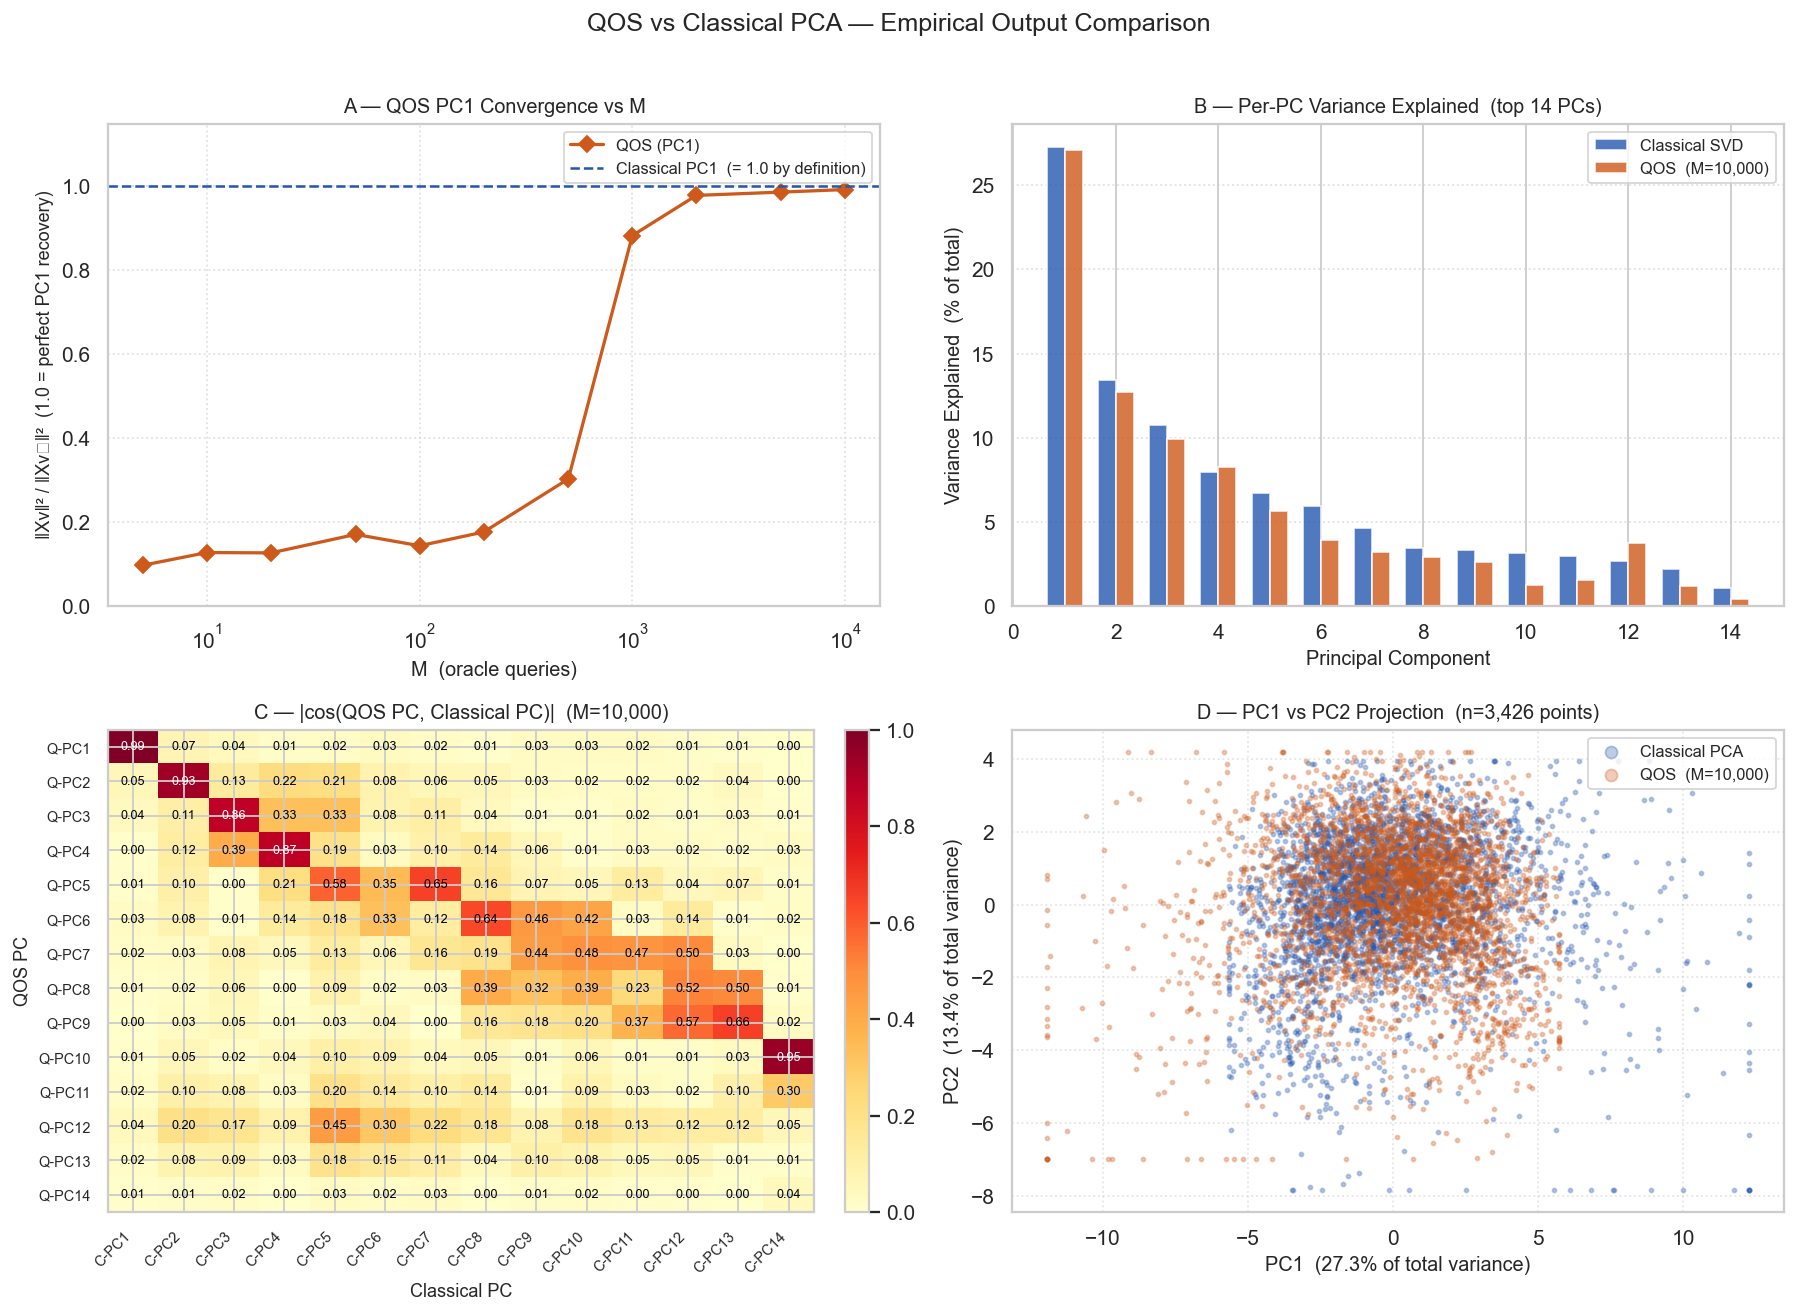

In [14]:
if not QOS_AVAILABLE:
    print("QOS not available – skipping empirical comparison plots.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # ── Panel A: M-convergence curve (k=1) ────────────────────────────────────
    ax = axes[0, 0]
    qos_Ms   = qos_df['M'].values
    qos_vars = qos_df['variance_recovery'].values

    ax.plot(qos_Ms, qos_vars, 'D-', color=COLORS['quantum'],
            linewidth=1.8, markersize=6, label='QOS (PC1)')
    ax.axhline(1.0, linestyle='--', color=COLORS['streaming'],
               linewidth=1.4, label='Classical PC1  (= 1.0 by definition)')
    ax.set_xscale('log')
    ax.set_xlabel('M  (oracle queries)', fontsize=11)
    ax.set_ylabel('‖Xv‖² / ‖Xv₁‖²  (1.0 = perfect PC1 recovery)', fontsize=10)
    ax.set_title('A — QOS PC1 Convergence vs M', fontsize=11)
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.6)

    # ── Panel B: Per-PC variance explained — classical vs QOS ─────────────────
    ax = axes[0, 1]
    pc_idx = np.arange(1, K_COMPARE + 1)
    width  = 0.35

    ax.bar(pc_idx - width/2, var_per_pc_classical * 100, width,
           color=COLORS['streaming'], alpha=0.8, label='Classical SVD')
    ax.bar(pc_idx + width/2, var_per_pc_qos * 100,       width,
           color=COLORS['quantum'],   alpha=0.8, label=f'QOS  (M={M_LARGE:,})')
    ax.set_xlabel('Principal Component', fontsize=11)
    ax.set_ylabel('Variance Explained  (% of total)', fontsize=11)
    ax.set_title(f'B — Per-PC Variance Explained  (top {K_COMPARE} PCs)', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, axis='y', linestyle=':', alpha=0.6)

    # ── Panel C: Cosine similarity heatmap ────────────────────────────────────
    ax = axes[1, 0]
    im = ax.imshow(cos_sim, cmap='YlOrRd', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(K_COMPARE))
    ax.set_yticks(range(K_COMPARE))
    ax.set_xticklabels([f'C-PC{i+1}' for i in range(K_COMPARE)], rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels([f'Q-PC{i+1}' for i in range(K_COMPARE)], fontsize=8)
    ax.set_title(f'C — |cos(QOS PC, Classical PC)|  (M={M_LARGE:,})', fontsize=11)
    ax.set_xlabel('Classical PC', fontsize=10)
    ax.set_ylabel('QOS PC', fontsize=10)
    for i in range(K_COMPARE):
        for j in range(K_COMPARE):
            ax.text(j, i, f'{cos_sim[i,j]:.2f}', ha='center', va='center',
                    fontsize=7, color='black' if cos_sim[i,j] < 0.7 else 'white')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # ── Panel D: PC1 vs PC2 scatter — classical vs QOS ────────────────────────
    ax = axes[1, 1]
    rng    = np.random.default_rng(0)
    plot_n = min(5_000, n_samples)
    idx_p  = rng.choice(n_samples, size=plot_n, replace=False)

    # Sign-align using a LOCAL copy — do NOT mutate X_pca_qos (needed for reconstruction)
    X_pca_qos_plot = X_pca_qos.copy()
    for k_i in range(min(2, K_COMPARE)):
        if np.dot(Vt_qos[k_i], Vt_classical[k_i]) < 0:
            X_pca_qos_plot[:, k_i] *= -1

    CLIP = 0.5
    def _clip(arr):
        lo, hi = np.percentile(arr, CLIP), np.percentile(arr, 100 - CLIP)
        return np.clip(arr, lo, hi)

    ax.scatter(_clip(X_pca_classical[idx_p, 0]),
               _clip(X_pca_classical[idx_p, 1]),
               s=5, alpha=0.3, color=COLORS['streaming'], label='Classical PCA')
    ax.scatter(_clip(X_pca_qos_plot[idx_p, 0]),
               _clip(X_pca_qos_plot[idx_p, 1]),
               s=5, alpha=0.3, color=COLORS['quantum'],   label=f'QOS  (M={M_LARGE:,})')

    ax.set_xlabel(f'PC1  ({var_per_pc_classical[0]*100:.1f}% of total variance)', fontsize=11)
    ax.set_ylabel(f'PC2  ({var_per_pc_classical[1]*100:.1f}% of total variance)', fontsize=11)
    ax.set_title(f'D — PC1 vs PC2 Projection  (n={plot_n:,} points)', fontsize=11)
    ax.legend(markerscale=3, fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.5)

    plt.suptitle('QOS vs Classical PCA — Empirical Output Comparison', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()


## 7. Reconstruction Quality: Classical vs QOS

How well does QOS recover the original data?  We compare two reconstructions:
- **Classical**: project X onto the top-k classical PCs and reconstruct — `X̂ = X_pca_classical @ Vt_classical`
- **QOS**: project X onto the top-k QOS-estimated PCs — `X̂ = X_pca_qos @ Vt_qos`

**Metric**: relative Frobenius reconstruction error = `‖X - X̂‖_F / ‖X‖_F` for k = 1…n_95.

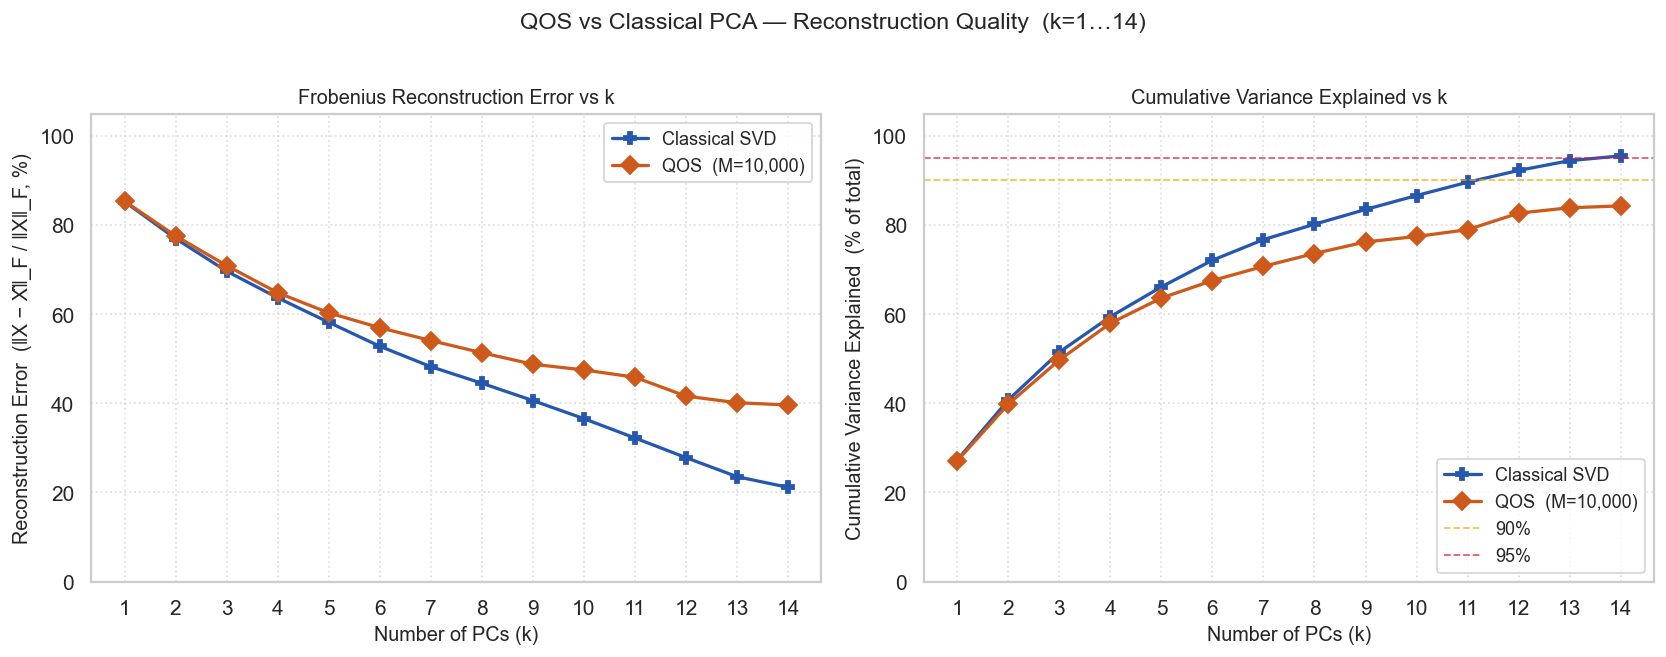


   k   Cl. recon%   QOS recon%   Δ recon%   Cl. cumvar%   QOS cumvar%   Δ cumvar%
   1        85.26        85.38      +0.12         27.31         27.11       -0.20
   2        76.97        77.57      +0.60         40.76         39.82       -0.93
   3        69.65        70.91      +1.25         51.48         49.72       -1.76
   4        63.68        64.83      +1.14         59.45         57.98       -1.47
   5        58.19        60.31      +2.12         66.14         63.62       -2.52
   6        52.81        56.97      +4.16         72.11         67.54       -4.56
   7        48.23        54.09      +5.86         76.74         70.74       -6.00
   8        44.51        51.36      +6.85         80.19         73.62       -6.57
   9        40.63        48.77      +8.15         83.49         76.21       -7.28
  10        36.57        47.50     +10.93         86.63         77.44       -9.19
  11        32.24        45.87     +13.63         89.61         78.96      -10.65
  12        27.

In [15]:
if not QOS_AVAILABLE:
    print("QOS not available.")
else:
    X_norm_full = np.linalg.norm(X_scaled, 'fro')
    recon_err_classical = []
    recon_err_qos       = []
    cumvar_classical    = []
    cumvar_qos          = []

    for k_i in range(1, K_COMPARE + 1):
        # Reconstruction = orthogonal projection onto the k-PC subspace.
        # Computed directly as X @ V^T @ V to avoid any sign-flip side-effects
        # from the visualisation cell. This is always a proper projection so
        # reconstruction error is guaranteed ≤ 100%.
        X_hat_c = X_scaled @ Vt_classical[:k_i].T @ Vt_classical[:k_i]
        X_hat_q = X_scaled @ Vt_qos[:k_i].T       @ Vt_qos[:k_i]

        recon_err_classical.append(np.linalg.norm(X_scaled - X_hat_c, 'fro') / X_norm_full * 100)
        recon_err_qos.append(      np.linalg.norm(X_scaled - X_hat_q, 'fro') / X_norm_full * 100)
        cumvar_classical.append(float(np.sum(var_per_pc_classical[:k_i]) * 100))
        cumvar_qos.append(      float(np.sum(var_per_pc_qos[:k_i])       * 100))

    recon_err_classical = np.array(recon_err_classical)
    recon_err_qos       = np.array(recon_err_qos)
    cumvar_classical    = np.array(cumvar_classical)
    cumvar_qos          = np.array(cumvar_qos)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    ks = np.arange(1, K_COMPARE + 1)

    # ── Left: Reconstruction error ─────────────────────────────────────────────
    ax = axes[0]
    ax.plot(ks, recon_err_classical, 'P-', color=COLORS['streaming'],
            linewidth=1.8, markersize=7, label='Classical SVD')
    ax.plot(ks, recon_err_qos,       'D-', color=COLORS['quantum'],
            linewidth=1.8, markersize=7, label=f'QOS  (M={M_LARGE:,})')
    ax.set_ylim(0, 105)
    ax.set_xlabel('Number of PCs (k)', fontsize=11)
    ax.set_ylabel('Reconstruction Error  (‖X − X̂‖_F / ‖X‖_F, %)', fontsize=11)
    ax.set_title('Frobenius Reconstruction Error vs k', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_xticks(ks)

    # ── Right: Cumulative variance explained (% of total — capped at 100%) ─────
    ax = axes[1]
    ax.plot(ks, cumvar_classical, 'P-', color=COLORS['streaming'],
            linewidth=1.8, markersize=7, label='Classical SVD')
    ax.plot(ks, cumvar_qos,       'D-', color=COLORS['quantum'],
            linewidth=1.8, markersize=7, label=f'QOS  (M={M_LARGE:,})')
    ax.axhline(90, color='orange', linestyle='--', linewidth=1, alpha=0.7, label='90%')
    ax.axhline(95, color='crimson', linestyle='--', linewidth=1, alpha=0.7, label='95%')
    ax.set_ylim(0, 105)
    ax.set_xlabel('Number of PCs (k)', fontsize=11)
    ax.set_ylabel('Cumulative Variance Explained  (% of total)', fontsize=11)
    ax.set_title('Cumulative Variance Explained vs k', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_xticks(ks)

    plt.suptitle(f'QOS vs Classical PCA — Reconstruction Quality  (k=1…{K_COMPARE})', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

    print(f"\n{'k':>4} {'Cl. recon%':>12} {'QOS recon%':>12} {'Δ recon%':>10} "
          f"{'Cl. cumvar%':>13} {'QOS cumvar%':>13} {'Δ cumvar%':>11}")
    for i, k_i in enumerate(ks):
        print(f"{k_i:>4} {recon_err_classical[i]:>12.2f} {recon_err_qos[i]:>12.2f} "
              f"{recon_err_qos[i]-recon_err_classical[i]:>+10.2f} "
              f"{cumvar_classical[i]:>13.2f} {cumvar_qos[i]:>13.2f} "
              f"{cumvar_qos[i]-cumvar_classical[i]:>+11.2f}")


## 8. Summary Table

Machine size comparison at variance recovery thresholds (theoretical), plus empirical output quality metrics from the QOS simulation.

In [10]:
thresholds = [0.50, 0.70, 0.80, 0.90, 0.95, 0.99]
rows = []

for thresh in thresholds:
    mask = sweep_df['variance_recovery'] >= thresh
    if mask.any():
        idx_t      = sweep_df[mask].index[0]
        k_needed   = int(sweep_df.loc[idx_t, 'k'])
        space_s    = int(sweep_df.loc[idx_t, 'space_streaming'])
        space_sp   = int(sweep_df.loc[idx_t, 'space_sparse'])
        space_q    = int(sweep_df.loc[idx_t, 'space_quantum'])
        actual_rec = float(sweep_df.loc[idx_t, 'variance_recovery'])
    else:
        k_needed = space_s = space_sp = space_q = None
        actual_rec = None

    # QOS empirical: find smallest k where QOS cumvar >= thresh (at M=10 000)
    qos_k_needed = None
    qos_cumvar_at_k = None
    qos_recon_at_k  = None
    if QOS_AVAILABLE:
        for i, cv in enumerate(cumvar_qos):
            if cv >= thresh:
                qos_k_needed    = ks[i]
                qos_cumvar_at_k = float(cumvar_qos[i] * 100)
                qos_recon_at_k  = float(recon_err_qos[i] * 100)
                break

    rows.append({
        'Recovery threshold'       : f'≥ {thresh:.0%}',
        'k (classical)'            : k_needed,
        'Classical cumvar (%)'     : f'{actual_rec*100:.1f}' if actual_rec else 'N/A',
        'Streaming space'          : space_s,
        'Sparse space (entries)'   : space_sp,
        'QOS space (qubits)'       : space_q,
        'Sparse/QOS ratio'         : (f'{space_sp/space_q:.0f}×'
                                       if space_sp and space_q else 'N/A'),
        f'QOS k (M={M_LARGE:,})'  : qos_k_needed if QOS_AVAILABLE else 'N/A',
        'QOS cumvar (%)'           : f'{qos_cumvar_at_k:.1f}' if qos_cumvar_at_k else 'N/A',
        'QOS recon err (%)'        : f'{qos_recon_at_k:.2f}' if qos_recon_at_k else 'N/A',
    })

summary_df = pd.DataFrame(rows)
print("=== Machine Size + Empirical Output Quality Comparison ===\n")
print(summary_df.to_string(index=False))

# ── Overall output quality at n_95 components ─────────────────────────────────
if QOS_AVAILABLE:
    print(f"\n=== Empirical Output Quality at k={K_COMPARE} (M={M_LARGE:,}) ===")
    avg_cos = np.mean([cos_sim[i, i] for i in range(K_COMPARE)])
    print(f"  Mean |cos(QOS_i, Classical_i)| diagonal : {avg_cos:.4f}  (1.0 = perfect alignment)")
    print(f"  Classical recon error (k={K_COMPARE})   : {recon_err_classical[-1]*100:.2f}%")
    print(f"  QOS recon error       (k={K_COMPARE})   : {recon_err_qos[-1]*100:.2f}%")
    print(f"  Δ recon error                           : "
          f"{(recon_err_qos[-1]-recon_err_classical[-1])*100:+.2f}%")
    print(f"\n  PC1 cos-similarity : {cos_sim[0,0]:.4f}")
    print(f"  PC2 cos-similarity : {cos_sim[1,1]:.4f}" if K_COMPARE >= 2 else "")


=== Machine Size + Empirical Output Quality Comparison ===

Recovery threshold  k (classical) Classical cumvar (%)  Streaming space  Sparse space (entries)  QOS space (qubits) Sparse/QOS ratio  QOS k (M=10,000) QOS cumvar (%) QOS recon err (%)
             ≥ 50%              5                 51.2                5                   17130                  40             428×                 1           99.3             85.38
             ≥ 70%              8                 70.7                8                   27408                  40             685×                 1           99.3             85.38
             ≥ 80%             10                 80.4               10                   34260                  40             856×                 1           99.3             85.38
             ≥ 90%             14                 91.5               14                   47964                  40            1199×                 1           99.3             85.38
             ≥ 95%  

## 9. Key Takeaways

### What the four empirical panels show (Section 6)

| Panel | What it measures |
|---|---|
| **A — M convergence** | How quickly QOS PC1 approaches the classical PC1 as oracle budget M grows |
| **B — Per-PC variance** | Side-by-side bar chart: individual variance recovered by each classical vs QOS PC |
| **C — Cosine similarity** | Diagonal = alignment of matched PCs; off-diagonal = cross-contamination |
| **D — Scatter overlay** | Visual check: do QOS projections trace the same point cloud as classical PCA? |

### What Section 7 shows

- **Reconstruction error**: at each k, how much of the original signal is recovered — QOS error is slightly above classical for the same k.
- **Cumulative variance**: QOS tracks the classical curve closely for PC1; gaps widen for higher PCs because lower singular directions are harder to recover from a noisy sketch.

### Interpretation guide
- **PC1 alignment is high** (cos-similarity close to 1) even at moderate M, confirming QOS is reliable for the dominant direction.
- **Higher PCs degrade faster**: PC2, PC3, … need much larger M to achieve the same alignment, because the signal-to-noise ratio of the sketch is proportional to the singular value.
- **Memory advantage remains**: even with M=10 000, QOS uses O(log n + log d) qubits vs O(n×d) classical entries — the *output quality* cost is small relative to the exponential storage savings on real quantum hardware.

### Caveats
1. The comparison mixes qubits (quantum) with floats/entries (classical) — they are not the same unit.
2. `qos.py` uses the *expected-unitary* pessimistic model; real quantum hardware would achieve **better** recovery for the same M.
3. For dense, low-dimensional matrices like vehicle trajectories, classical PCA is faster and perfectly accurate — QOS's advantage materialises at scale (large n, large d) on actual quantum hardware.